In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting ke liye style set karte hain
plt.style.use('fivethirtyeight')
%matplotlib inline

# 1. Data Load Karo (Apni file ka sahi naam/path likhein)
# Agar data 'data' folder mein hai toh: pd.read_csv('../data/your_file.csv')
df = pd.read_csv('C:\\Users\\LENOVO\\Multi_Series_Forecasting_for_Retail_Demand_Optimization\\data\\raw\\training.csv') # Ya jo bhi aapki main data file hai

print("📊 Dataset Shape:", df.shape)
print("\n📋 Pahle 5 Rows:")
df.head(100)

📊 Dataset Shape: (913000, 4)

📋 Pahle 5 Rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
95,2013-04-06,1,1,23
96,2013-04-07,1,1,17
97,2013-04-08,1,1,19
98,2013-04-09,1,1,13


In [6]:
print("ℹ️ Data Information:")
df.info()

print("\n❌ Missing Values Count:")
print(df.isnull().sum())

print("\n🔢 Unique Counts (Stores, Items, etc.):")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

ℹ️ Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 36.6 MB

❌ Missing Values Count:
date     0
store    0
item     0
sales    0
dtype: int64

🔢 Unique Counts (Stores, Items, etc.):
date: 1826 unique values
store: 10 unique values
item: 50 unique values
sales: 213 unique values


In [7]:
# Maan lete hain column ka naam 'date' hai, agar 'Date' hai toh capital D likhna
df['date'] = pd.to_datetime(df['date'])

# Date ko index banate hain plots ke liye
df.set_index('date', inplace=True)

print("📅 Date Range:", df.index.min(), "se", df.index.max())

📅 Date Range: 2013-01-01 00:00:00 se 2017-12-31 00:00:00


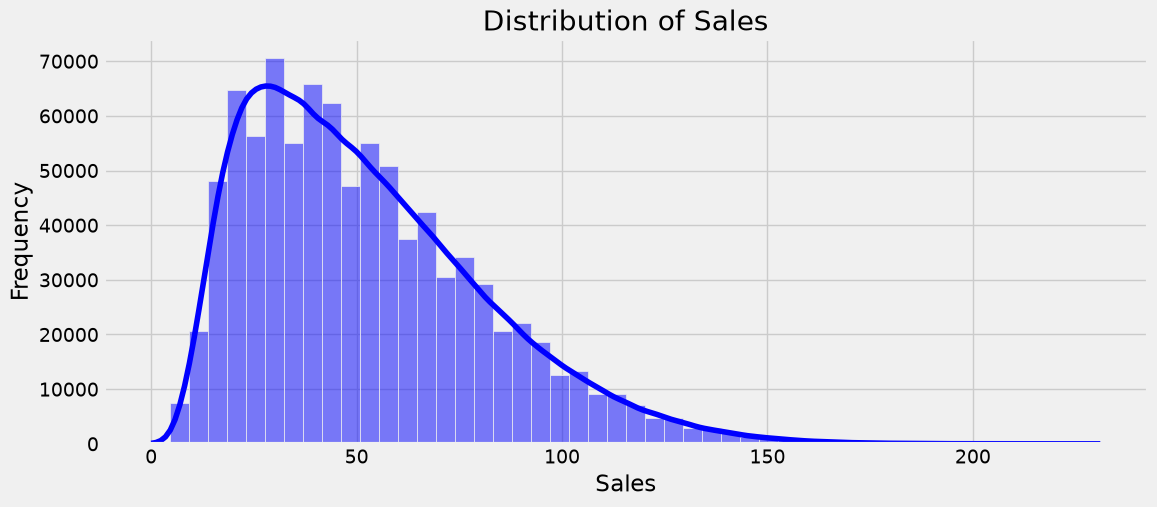

In [8]:
# Maan lete hain target column ka naam 'sales' ya 'demand' hai
target_col = 'sales' # Isko apne column ke hisaab se badal lena

plt.figure(figsize=(12, 5))
sns.histplot(df[target_col], kde=True, bins=50, color='blue')
plt.title(f'Distribution of {target_col.capitalize()}')
plt.xlabel(target_col.capitalize())
plt.ylabel('Frequency')
plt.show()

<Figure size 1400x600 with 0 Axes>

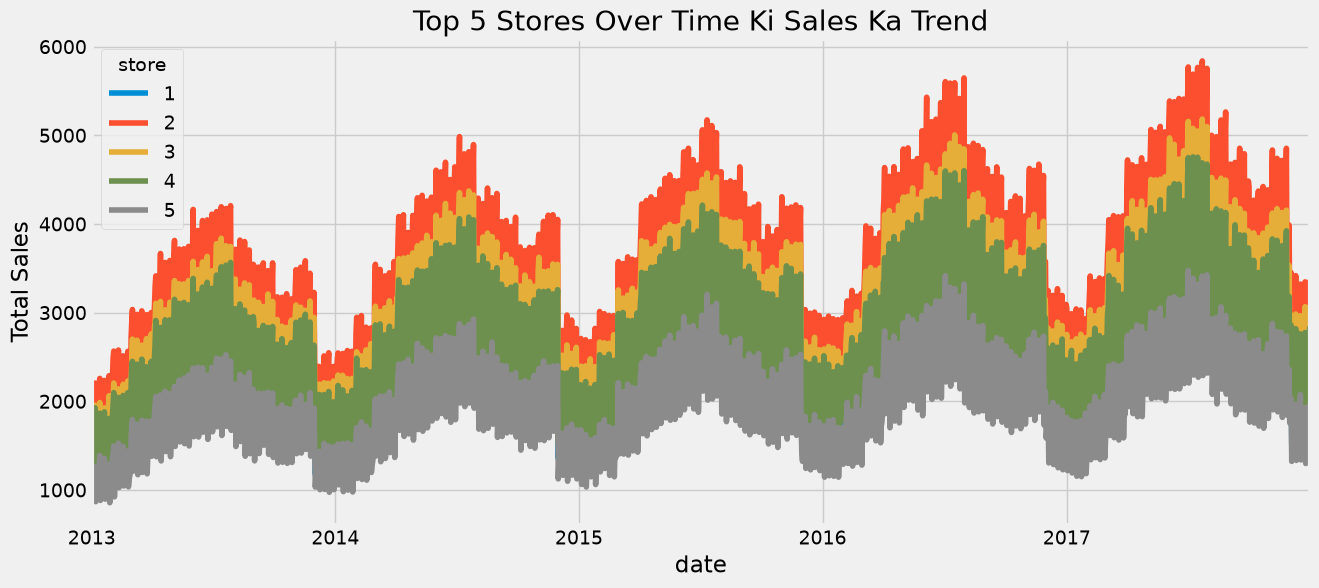

In [9]:
# Maan lete hain columns ke naam 'store' aur 'item' hain
if 'store' in df.columns:
    plt.figure(figsize=(14, 6))
    # Top 5 stores ka overall sales trend breakdown
    df.groupby(['date', 'store'])[target_col].sum().unstack().iloc[:, :5].plot(figsize=(14,6))
    plt.title('Top 5 Stores Over Time Ki Sales Ka Trend')
    plt.ylabel('Total Sales')
    plt.grid(True)
    plt.show()

<Figure size 1400x600 with 0 Axes>

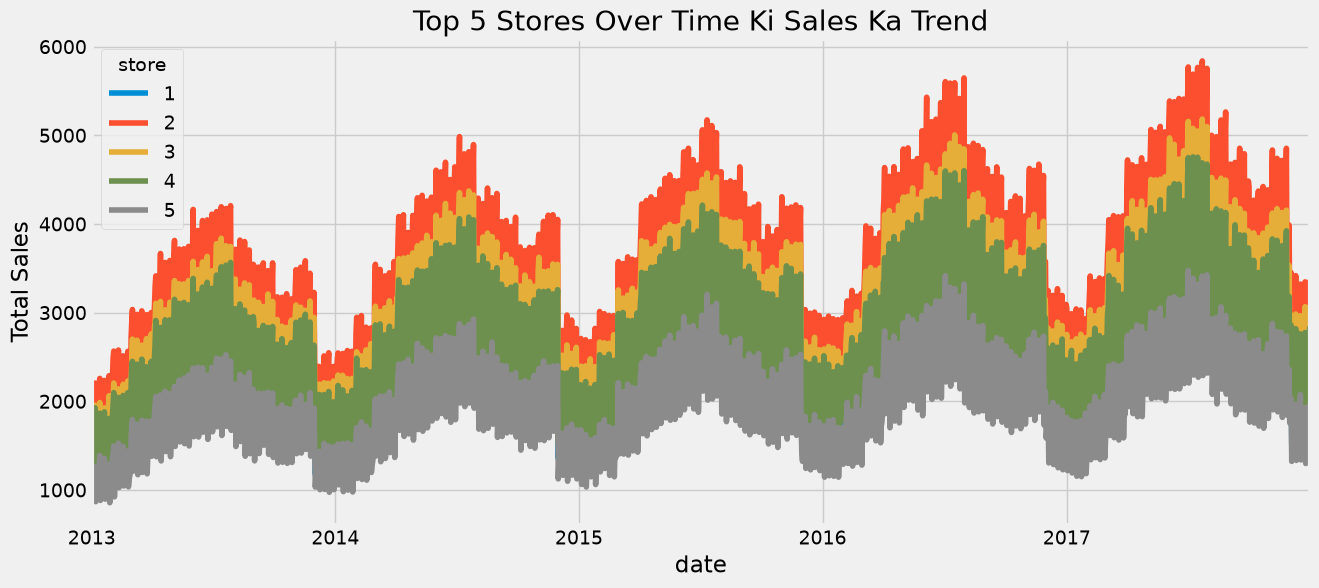

In [10]:
# Maan lete hain columns ke naam 'store' aur 'item' hain
if 'store' in df.columns:
    plt.figure(figsize=(14, 6))
    # Top 5 stores ka overall sales trend breakdown
    df.groupby(['date', 'store'])[target_col].sum().unstack().iloc[:, :5].plot(figsize=(14,6))
    plt.title('Top 5 Stores Over Time Ki Sales Ka Trend')
    plt.ylabel('Total Sales')
    plt.grid(True)
    plt.show()

<Figure size 1400x600 with 0 Axes>

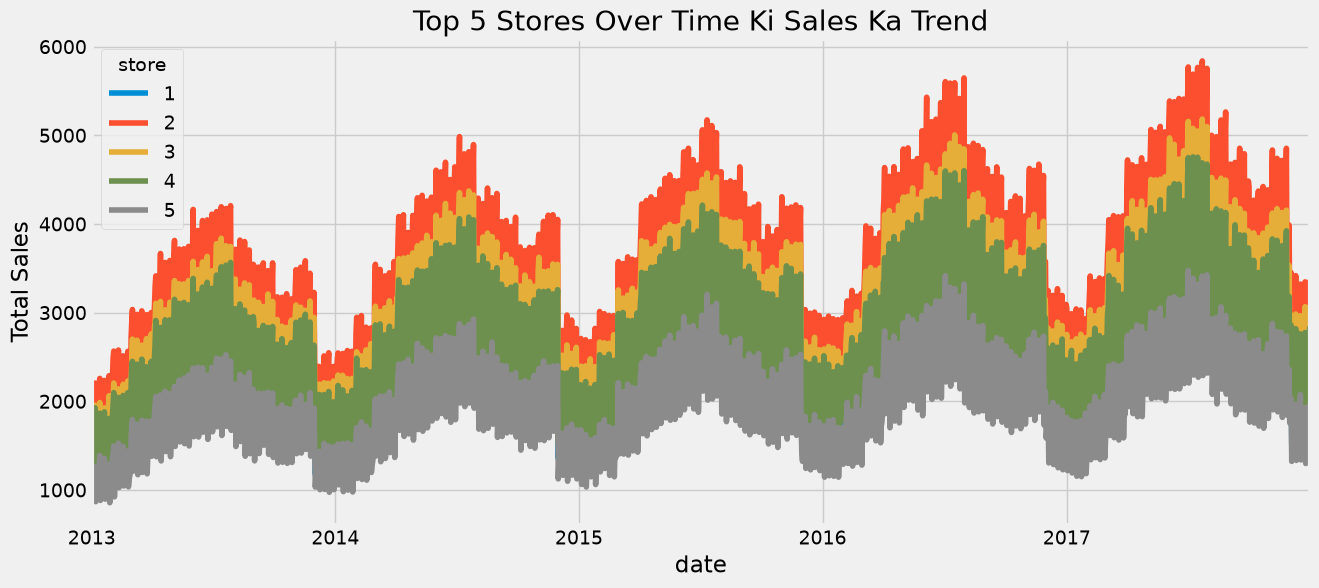

In [11]:
# Maan lete hain columns ke naam 'store' aur 'item' hain
if 'store' in df.columns:
    plt.figure(figsize=(14, 6))
    # Top 5 stores ka overall sales trend breakdown
    df.groupby(['date', 'store'])[target_col].sum().unstack().iloc[:, :5].plot(figsize=(14,6))
    plt.title('Top 5 Stores Over Time Ki Sales Ka Trend')
    plt.ylabel('Total Sales')
    plt.grid(True)
    plt.show()

In [13]:
# 1. IQR Calculate karo
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

# Bounds set karo
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outliers filter karo
outliers_iqr = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

print(f"🔹 IQR Lower Bound (Min Safe Sales): {lower_bound:.2f}")
print(f"🔹 IQR Upper Bound (Max Safe Sales): {upper_bound:.2f}")
print(f"🚨 Total Outliers Detected (IQR): {len(outliers_iqr)} rows")
print(f"📉 Percentage of Outliers: {(len(outliers_iqr) / len(df)) * 100:.2f}%")

plt.show()

🔹 IQR Lower Bound (Min Safe Sales): -30.00
🔹 IQR Upper Bound (Max Safe Sales): 130.00
🚨 Total Outliers Detected (IQR): 11967 rows
📉 Percentage of Outliers: 1.31%


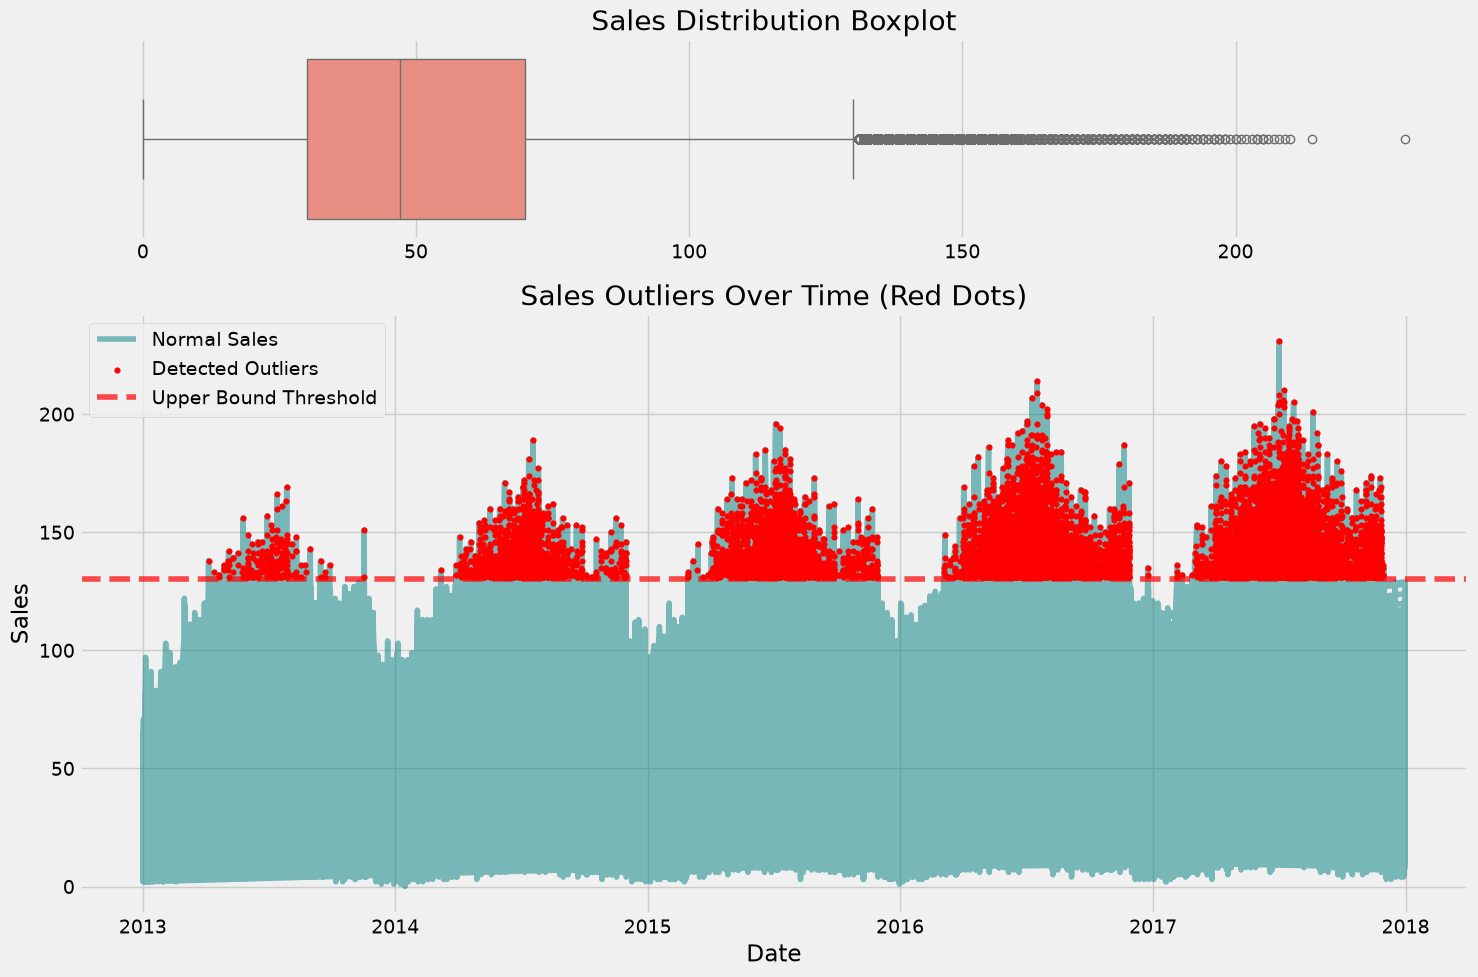

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [1, 3]})

# 1. Boxplot (Distribution dekhne ke liye)
sns.boxplot(x=df[target_col], ax=axes[0], color='salmon')
axes[0].set_title('Sales Distribution Boxplot')
axes[0].set_xlabel('')

# 2. Scatter Plot over Time (Kis date ko outlier aaya)
axes[1].plot(df.index, df[target_col], label='Normal Sales', alpha=0.5, color='teal')
# Outliers ko red dots se highlight karte hain
axes[1].scatter(outliers_iqr.index, outliers_iqr[target_col], color='red', label='Detected Outliers', s=15, zorder=5)
axes[1].axhline(upper_bound, color='red', linestyle='--', alpha=0.7, label='Upper Bound Threshold')

axes[1].set_title('Sales Outliers Over Time (Red Dots)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales')
axes[1].legend()

plt.tight_layout()
plt.show()